<a href="https://colab.research.google.com/github/akashhhshsh/Fish-Disease/blob/main/Let's_classify_fish_pictures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'tilapia-fish-fresh-and-non-fresh-species:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F4659399%2F7927851%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240930%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240930T085224Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D48ee6e061afef084efbf7e2cf0e306c41b9d17c0da6796aae7f2dc2fa771f50b73b6dfed0a2efcaddf45ad1927685607b1317e3a54da2b5fb650bc0456de3e1b3d95802833c10303ae6164e9a0e10aac7a5e6c7f1f3c319279f39aae2af299e8ca5ccdc1a07fc39aac1dc0209605659912855e6430b778ef36edbdef884330a1100e3ebfcec164f4667edc760e02f5c26ec819aba5d08d99eff8813161141965de72563034aada13b67e263685c3aac6bbe93c56ee94583482eef2327247c3b19f158c982bf0088583738d2a929ba73251744a8d761e13e99c0a21f26749307205fe3d0c92cb485267b2e05d1249c24de24b326ae197265cfd1ff9e9f1fc001c'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 319800450 bytes downloaded
Downloaded and uncompressed: tilapia-fish-fresh-and-non-fresh-species
Data source import complete.


In [2]:
!pip install --upgrade --quiet pip
!pip install --quiet img2vec_pytorch
print('pip install/update complete.')

pip install/update complete.


Let's load up our data, get our embeddings, and make thumbnails; this will take about ten minutes but it's time well spent.

In [4]:
    !pip install arrow img2vec-pytorch
    import base64
    import pandas as pd

    from glob import glob
    from io import BytesIO
    from os.path import basename

    from arrow import now
    from img2vec_pytorch import Img2Vec
    from PIL import Image

    SIZE = 512
    STOP =  10000
    DATA_GLOB = '/kaggle/input/tilapia-fish-fresh-and-non-fresh-species/Kaggle_upload'

    # https://stackoverflow.com/a/952952
    def flatten(arg):
        return [x for xs in arg for x in xs]

    def get_from_glob(arg: str, tag: str, stop: int) -> list:
        time_get = now()
        result = []
        for index, input_file in enumerate(glob(pathname=arg, recursive=True)):
            if index < stop:
                name = input_file.replace(DATA_GLOB, '')
                with Image.open(fp=input_file, mode='r') as image:
                    vector = img2vec.get_vec(image, tensor=True).numpy().reshape(SIZE,)
                    buffer = BytesIO()
                    size = (128, 128)
                    image.resize(size=size).save(buffer, format='png')
                    result.append(pd.Series(data=[tag, name, vector,
                                                  'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode(),
                                                 ], index=['tag', 'name', 'value', 'image']))
        print('encoded {} data {} rows in {}'.format(tag, len(result), now() - time_get))
        return result

    img2vec = Img2Vec(cuda=False, model='resnet-18', layer='default', layer_output_size=SIZE)

    time_start = now()

    files = {basename(folder) : folder + '/*/*/*.jpg' for folder in glob(DATA_GLOB + '/*')}
    data = [get_from_glob(arg=value, tag=key, stop=STOP) for key, value in files.items()]
    df = pd.DataFrame(data=flatten(arg=data))

    print('done in {}'.format(now() - time_start))

encoded Fresh_Day1 data 3322 rows in 0:09:35.756575
encoded NonFresh data 2397 rows in 0:06:41.796619
done in 0:16:18.326316


In [5]:
from plotly import express
express.pie(data_frame=df, names='tag', color='tag')

Our classes are unbalanced but not severely so. Our fresh fish outnumber our other fish about three to two.

In [6]:
!pip install umap-learn
from arrow import now
from umap import UMAP

time_start = now()
umap = UMAP(random_state=2024, verbose=True, n_jobs=1, low_memory=False, n_epochs=201)
df[['x', 'y']] = umap.fit_transform(X=df['value'].apply(func=pd.Series))
print('done with UMAP in {}'.format(now() - time_start))

UMAP(low_memory=False, n_epochs=201, n_jobs=1, random_state=2024, verbose=True)
Mon Sep 30 09:37:32 2024 Construct fuzzy simplicial set
Mon Sep 30 09:37:32 2024 Finding Nearest Neighbors
Mon Sep 30 09:37:32 2024 Building RP forest with 9 trees
Mon Sep 30 09:37:39 2024 NN descent for 12 iterations
	 1  /  12
	 2  /  12
	 3  /  12
	Stopping threshold met -- exiting after 3 iterations
Mon Sep 30 09:37:59 2024 Finished Nearest Neighbor Search
Mon Sep 30 09:38:03 2024 Construct embedding


Epochs completed:   0%|            0/201 [00:00]

	completed  0  /  201 epochs
	completed  20  /  201 epochs
	completed  40  /  201 epochs
	completed  60  /  201 epochs
	completed  80  /  201 epochs
	completed  100  /  201 epochs
	completed  120  /  201 epochs
	completed  140  /  201 epochs
	completed  160  /  201 epochs
	completed  180  /  201 epochs
	completed  200  /  201 epochs
Mon Sep 30 09:38:10 2024 Finished embedding
done with UMAP in 0:00:38.188177


In [7]:
import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
express.scatter(data_frame=df, x='x', y='y', color='tag')

In [8]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Set1_3
from bokeh.transform import factor_cmap

output_notebook()

# we are resource limited so we need to take a sample
datasource = ColumnDataSource(df.sample(n=2000, random_state=2024))
mapper = factor_cmap(field_name = 'tag', palette=Set1_3, factors=['Fresh_Day1', 'NonFresh', ], start=0, end=3)

plot_figure = figure(title='UMAP projection: fish freshness', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@image' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 16px; color: #224499'>tag:</span>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.circle('x', 'y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=5, color=mapper)
show(plot_figure)


Buffered data was truncated after reaching the output size limit.

We have a lot of clustering and separation in our UMAP, plot, so we expect a model to do well. Let's find out.

In [9]:
import arrow
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['value'].apply(func=pd.Series), df['tag'], test_size=0.99, random_state=2024, stratify=df['tag'])

time_start = arrow.now()
model = LogisticRegression(max_iter=100000, tol=1e-4).fit(X=X_train, y=y_train)
print('model fit in {} iterations took {}'.format(model.n_iter_[0], arrow.now() - time_start))

print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=model.predict(X=X_test))))
print('model done in {}'.format(now() - time_start))

model fit in 20 iterations took 0:00:00.157457
accuracy: 0.9730
model done in 0:00:00.417917


It turns out we must have a lot of duplication in our data, because we're training on a small sample and our model has a low tolerance, but we still get essentially no errors.

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=model.predict(X=X_test)))

              precision    recall  f1-score   support

  Fresh_Day1       0.96      0.99      0.98      3289
    NonFresh       0.99      0.94      0.97      2373

    accuracy                           0.97      5662
   macro avg       0.98      0.97      0.97      5662
weighted avg       0.97      0.97      0.97      5662



In [11]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print('Train Accuracy:', train_accuracy)
print('Test Accuracy:', test_accuracy)


Train Accuracy: 1.0
Test Accuracy: 0.9729777463793713


In [12]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print('Cross-Validation Scores:', cv_scores)
print('Average Cross-Validation Score:', cv_scores.mean())


Cross-Validation Scores: [1.         0.91666667 1.         0.90909091 1.        ]
Average Cross-Validation Score: 0.9651515151515152


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


6 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1301, in fit
    raise ValueError(
ValueError: This solver needs samples of at least 2 cla

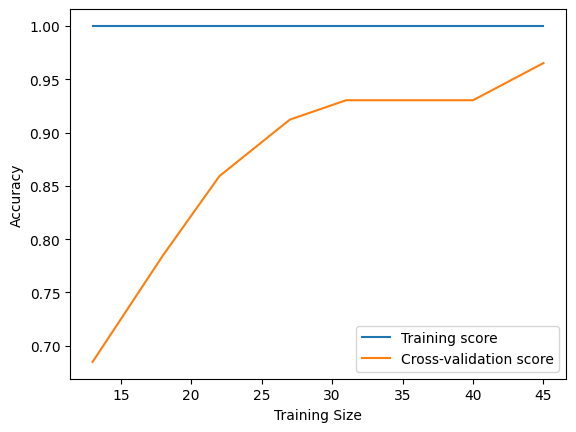

In [14]:
import numpy as np
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, test_mean, label='Cross-validation score')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
